In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load the corrected full image data and books data
df = pd.read_csv('/Users/nogashlomi/projects/Image_data/dissertation/full_image_data_feb_25_corrected_centrality_earth.csv', low_memory=False)
books = pd.read_csv('/Users/nogashlomi/projects/Image_data/dissertation/full_book_data_feb_25.csv', low_memory=False)

# Map publishers and printers
df['printer'] = df['book'].map(books.set_index('book')['printers'])
df['publisher'] = df['book'].map(books.set_index('book')['publishers'])

# Define the target cks values to plot
target_cks = [
    'CK_Negligible Dimensions of the Earth',
    'CK_Central Intersection of Eclipses',
    'CK_Visibility of Half of the Sky from the Central Earth',
    'CK_Apparent Size of Stars',
    'CK_Lunar Eclipse',
    'CK_The Assumed Parallelity of the Sun Rays'
]

# Drop rows where year or place or custom_identifier might be null for plotting
df_clean = df.dropna(subset=['year', 'place', 'custom_identifier']).copy()
df_clean['custom_identifier_str'] = df_clean['custom_identifier'].astype(int).astype(str)

print("Data loaded perfectly.")


In [ ]:
# We want to find books containing IMAGES that have BOTH 'Centrality of Earth' 
# AND the target keyword applied to the exact same image.

base_ck = 'CK_Centrality of Earth'

# 1. Get all unique Image IDs that have the Centrality of Earth keyword
images_with_base = set(df_clean[df_clean['cks'] == base_ck]['images'].unique())

print(f"Total Unique IMAGES containing '{base_ck}': {len(images_with_base)}\n")

# Scatter plots by Place and Text Part (Custom ID) for each keyword
for ck in target_cks:
    # 2. Get all unique Image IDs that have the Target CK
    images_with_target = set(df_clean[df_clean['cks'] == ck]['images'].unique())
    
    # 3. Find the exact intersection: Images that have BOTH Centrality AND the Target CK
    shared_images = images_with_base.intersection(images_with_target)
    
    # 4. Filter the dataframe down to just these specific overlapping images
    # We restrict to rows where 'cks' == ck to get the correct Text Part for that keyword 
    # (though for the same image it should be the same).
    df_ck = df_clean[(df_clean['images'].isin(shared_images)) & (df_clean['cks'] == ck)].copy()
    
    # 5. Drop duplicate books so we plot 1 dot per unique printed book that contains such an image
    df_ck = df_ck.drop_duplicates(subset=['book']).copy()
    
    print(f"===========================================================")
    print(f"Generating plots for: {ck} (Shared exact IMAGES with Centrality: {len(shared_images)} | Unique Books: {len(df_ck)})")
    
    if len(df_ck) == 0:
        print("Skipping - no books found after filtering.\n")
        continue

    # 1. Static Scatter Plot (Place on y-axis, colored by Custom ID)
    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        data=df_ck,
        x='year',
        y='place',
        hue='custom_identifier_str',
        palette='tab20',  
        s=80,
        alpha=0.7,
        legend=False 
    )
    plt.title(f'Printings of BOOKS containing "{ck}"\nOver Time and Place (Colored by Custom ID)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Place', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # 2. Interactive Scatter Plot (Place on y-axis)
    fig_place = px.scatter(
        df_ck,
        x='year',
        y='place',
        color='custom_identifier_str',
        hover_data=['part_or_adaption_label', 'images', 'bid', 'book'],
        title=f'Interactive Plot: BOOKS containing "{ck}" (by Place)',
        labels={'custom_identifier_str': 'Custom ID'}
    )
    fig_place.update_traces(marker=dict(size=8, opacity=0.7))
    fig_place.update_layout(height=800, hovermode='closest')
    fig_place.show()

    # 3. Static Scatter Plot (Custom ID on y-axis, colored by Place)
    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        data=df_ck, 
        x='year', 
        y='custom_identifier_str', 
        hue='place',
        palette='tab20', 
        s=80, 
        alpha=0.7, 
        legend=False 
    )
    plt.title(f'Printings of BOOKS containing "{ck}"\nOver Time and Custom ID (Colored by Place)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Custom ID (Text Part)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # 4. Interactive Scatter Plot (Custom ID on y-axis)
    fig_id = px.scatter(
        df_ck, 
        x='year', 
        y='custom_identifier_str', 
        color='place',
        hover_data=['part_or_adaption_label', 'images', 'bid', 'book'],
        title=f'Interactive Plot: BOOKS containing "{ck}" (by Custom ID)',
        labels={'custom_identifier_str': 'Custom ID', 'place': 'Place'}
    )
    fig_id.update_traces(marker=dict(size=8, opacity=0.7))
    fig_id.update_layout(height=800, hovermode='closest')
    fig_id.show()
    
    print("\n")


In [ ]:
# We want to find books containing IMAGES that have BOTH 'Centrality of Earth' 
# AND the target keyword applied to the exact same image.

base_ck = 'CK_Centrality of Earth'

# 1. Get all unique Image IDs that have the Centrality of Earth keyword
images_with_base = set(df_clean[df_clean['cks'] == base_ck]['images'].unique())

print(f"Total Unique IMAGES containing '{base_ck}': {len(images_with_base)}\n")

# Scatter plots by Place and Text Part (Custom ID) for each keyword
for ck in target_cks:
    # 2. Get all unique Image IDs that have the Target CK
    images_with_target = set(df_clean[df_clean['cks'] == ck]['images'].unique())
    
    # 3. Find the exact intersection: Images that have BOTH Centrality AND the Target CK
    shared_images = images_with_base.intersection(images_with_target)
    
    # 4. Filter the dataframe down to just these specific overlapping images
    # We restrict to rows where 'cks' == ck to get the correct Text Part for that keyword 
    # (though for the same image it should be the same).
    df_ck = df_clean[(df_clean['images'].isin(shared_images)) & (df_clean['cks'] == ck)].copy()
    
    # 5. Drop duplicate books so we plot 1 dot per unique printed book that contains such an image
    df_ck = df_ck.drop_duplicates(subset=['book']).copy()
    
    print(f"===========================================================")
    print(f"Generating plots for: {ck} (Shared exact IMAGES with Centrality: {len(shared_images)} | Unique Books: {len(df_ck)})")
    
    if len(df_ck) == 0:
        print("Skipping - no books found after filtering.\n")
        continue

    # 1. Static Scatter Plot (Place on y-axis, colored by Custom ID)
    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        data=df_ck,
        x='year',
        y='place',
        hue='custom_identifier_str',
        palette='tab20',  
        s=80,
        alpha=0.7,
        legend=False 
    )
    plt.title(f'Printings of BOOKS containing "{ck}"\nOver Time and Place (Colored by Custom ID)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Place', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # 2. Interactive Scatter Plot (Place on y-axis)
    fig_place = px.scatter(
        df_ck,
        x='year',
        y='place',
        color='custom_identifier_str',
        hover_data=['part_or_adaption_label', 'images', 'bid', 'book'],
        title=f'Interactive Plot: BOOKS containing "{ck}" (by Place)',
        labels={'custom_identifier_str': 'Custom ID'}
    )
    fig_place.update_traces(marker=dict(size=8, opacity=0.7))
    fig_place.update_layout(height=800, hovermode='closest')
    fig_place.show()

    # 3. Static Scatter Plot (Custom ID on y-axis, colored by Place)
    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        data=df_ck, 
        x='year', 
        y='custom_identifier_str', 
        hue='place',
        palette='tab20', 
        s=80, 
        alpha=0.7, 
        legend=False 
    )
    plt.title(f'Printings of BOOKS containing "{ck}"\nOver Time and Custom ID (Colored by Place)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Custom ID (Text Part)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # 4. Interactive Scatter Plot (Custom ID on y-axis)
    fig_id = px.scatter(
        df_ck, 
        x='year', 
        y='custom_identifier_str', 
        color='place',
        hover_data=['part_or_adaption_label', 'images', 'bid', 'book'],
        title=f'Interactive Plot: BOOKS containing "{ck}" (by Custom ID)',
        labels={'custom_identifier_str': 'Custom ID', 'place': 'Place'}
    )
    fig_id.update_traces(marker=dict(size=8, opacity=0.7))
    fig_id.update_layout(height=800, hovermode='closest')
    fig_id.show()
    
    print("\n")


In [ ]:
# NEW SECTION: Exclusive 'Centrality of Earth' Images
# We want to find images that are tagged with 'CK_Centrality of Earth' AND NO OTHER CKs.

print("\n" + "="*80)
print("ANALYZING EXCLUSIVE CENTRALITY OF EARTH IMAGES")
print("="*80 + "\n")

# 1. Group the dataframe by 'images' and gather all 'cks' for each image into a list/set
image_ck_groups = df_clean.groupby('images')['cks'].apply(set)

# 2. Find images where the SET of CKs is strictly equal to JUST {'CK_Centrality of Earth'}
base_ck = 'CK_Centrality of Earth'
exclusive_images = image_ck_groups[image_ck_groups == {base_ck}].index

print(f"Total EXCLUSIVE '{base_ck}' Images (No other CKs): {len(exclusive_images)}\n")

if len(exclusive_images) > 0:
    # 3. Filter DataFrame down to just these exclusive images
    df_exclusive = df_clean[df_clean['images'].isin(exclusive_images)].copy()
    
    # 4. Drop duplicate books to plot unique books with these exclusive images
    df_exclusive_books = df_exclusive.drop_duplicates(subset=['book']).copy()
    
    print(f"Total Unique Books containing EXCLUSIVE '{base_ck}' Images: {len(df_exclusive_books)}")
    
    # 5. Print out the unique labels found in this exclusive group
    unique_labels = df_exclusive_books['part_or_adaption_label'].dropna().unique()
    print("\nUnique Text Part Labels in this EXCLUSIVE group:")
    for label in sorted(unique_labels):
        print(f" - {label}")
    print("\n")

    # --- Plotting ---
    
    # 1. Static Scatter Plot (Place on y-axis, colored by Custom ID)
    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        data=df_exclusive_books,
        x='year',
        y='place',
        hue='custom_identifier_str',
        palette='tab20',  
        s=80,
        alpha=0.7,
        legend=False 
    )
    plt.title(f'Printings of BOOKS containing EXCLUSIVE "{base_ck}" Images\nOver Time and Place (Colored by Custom ID)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Place', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # 2. Interactive Scatter Plot (Place on y-axis)
    fig_place_ex = px.scatter(
        df_exclusive_books,
        x='year',
        y='place',
        color='custom_identifier_str',
        hover_data=['part_or_adaption_label', 'images', 'bid', 'book'],
        title=f'Interactive Plot: BOOKS containing EXCLUSIVE "{base_ck}" (by Place)',
        labels={'custom_identifier_str': 'Custom ID'}
    )
    fig_place_ex.update_traces(marker=dict(size=8, opacity=0.7))
    fig_place_ex.update_layout(height=800, hovermode='closest')
    fig_place_ex.show()

    # 3. Static Scatter Plot (Custom ID on y-axis, colored by Place)
    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        data=df_exclusive_books, 
        x='year', 
        y='custom_identifier_str', 
        hue='place',
        palette='tab20', 
        s=80, 
        alpha=0.7, 
        legend=False 
    )
    plt.title(f'Printings of BOOKS containing EXCLUSIVE "{base_ck}" Images\nOver Time and Custom ID (Colored by Place)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Custom ID (Text Part)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # 4. Interactive Scatter Plot (Custom ID on y-axis)
    fig_id_ex = px.scatter(
        df_exclusive_books, 
        x='year', 
        y='custom_identifier_str', 
        color='place',
        hover_data=['part_or_adaption_label', 'images', 'bid', 'book'],
        title=f'Interactive Plot: BOOKS containing EXCLUSIVE "{base_ck}" (by Custom ID)',
        labels={'custom_identifier_str': 'Custom ID', 'place': 'Place'}
    )
    fig_id_ex.update_traces(marker=dict(size=8, opacity=0.7))
    fig_id_ex.update_layout(height=800, hovermode='closest')
    fig_id_ex.show()
else:
    print("No exclusive Centrality of Earth images found.")


Number of Unique Books per Content Group (CKs) over Time:
               CK_Centrality of Earth  CK_Negligible Dimensions of the Earth  \
year_interval                                                                  
1470-1489                           5                                      5   
1490-1509                          18                                     18   
1510-1529                          13                                      9   
1530-1549                          31                                     20   
1550-1569                          50                                     35   
1570-1589                          43                                     34   
1590-1609                          35                                     32   
1610-1629                          13                                     13   
1630-1650                           3                                      3   

               CK_Central Intersection of Eclipses  \
year_in

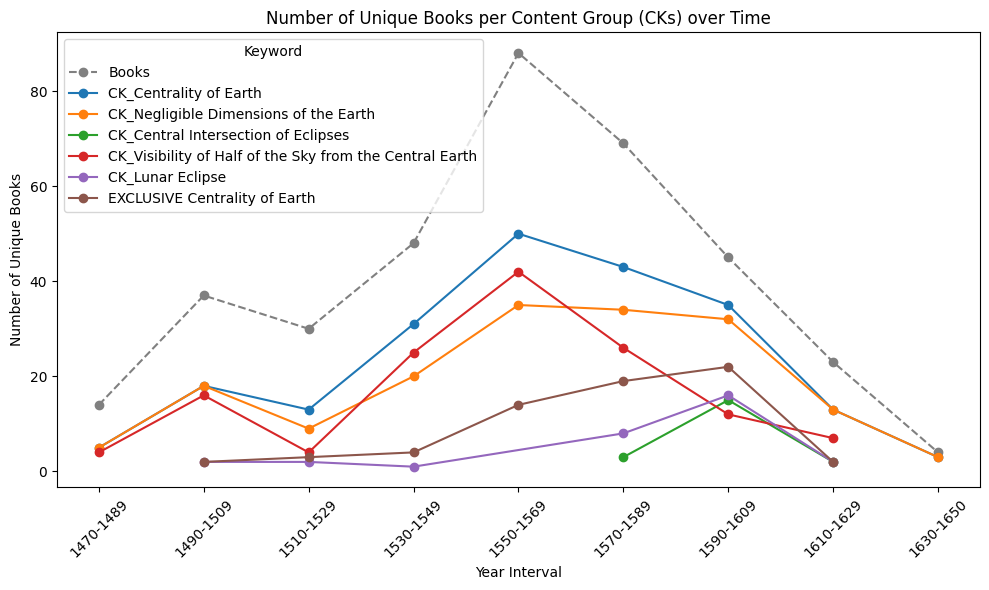

In [33]:
# Plot number of books with images with relevant cks tags that were defined at the top.
# Don't forget to update the file name in the save file line

target_timeline_cks = [
    'CK_Centrality of Earth',
    'CK_Negligible Dimensions of the Earth',
    'CK_Central Intersection of Eclipses',
    'CK_Visibility of Half of the Sky from the Central Earth',
    'CK_Lunar Eclipse',
]

# Get unique books per year_interval
unique_books_count = books.groupby('year_interval', observed=False)['book'].nunique()

# Define the master timeline from book data
intervals = unique_books_count.index.astype(str)

# We only want to plot the books where the Images BOTH have 'Centrality of Earth' AND the target keyword.
base_ck = 'CK_Centrality of Earth'
images_with_base = set(df_clean[df_clean['cks'] == base_ck]['images'].unique())

book_counts = {}
for keyword in target_timeline_cks:
    # Get all images for the target keyword
    images_with_target = set(df_clean[df_clean['cks'] == keyword]['images'].unique())
    # Intersect with Centrality of Earth images
    shared_images = images_with_base.intersection(images_with_target)
    
    # Calculate unique books containing these specific overlapping images
    book_counts[keyword] = (
        df_clean[(df_clean['images'].isin(shared_images)) & (df_clean['cks'] == keyword)]
        .groupby('year_interval', observed=False)['book']
        .nunique()
        .to_dict()
    )

# --- NEW SECTION: Calculate EXCLUSIVE 'Centrality of Earth' images ---
# 1. Group by image and collect the set of Content Keywords
image_ck_groups = df_clean.groupby('images')['cks'].apply(set)

# 2. Find images that ONLY contain 'CK_Centrality of Earth' (no other tags)
exclusive_images = image_ck_groups[image_ck_groups == {'CK_Centrality of Earth'}].index

# 3. Add their counts to the book_counts dictionary so they get graphed as a new line!
if len(exclusive_images) > 0:
    book_counts['EXCLUSIVE Centrality of Earth'] = (
        df_clean[df_clean['images'].isin(exclusive_images)]
        .drop_duplicates(subset=['book'])
        .groupby('year_interval', observed=False)['book']
        .nunique()
        .to_dict()
    )
# ---------------------------------------------------------------------

# ✅ Fix Problem 1: Reindex to match intervals
book_counts_df = pd.DataFrame(book_counts).reindex(unique_books_count.index).fillna(0)

# Add the total number of books to the DataFrame
book_counts_df['Books'] = unique_books_count

# Print the results as a table (zero values will be included)
print("Number of Unique Books per Content Group (CKs) over Time:")
print(book_counts_df)

# Start plotting
plt.figure(figsize=(10, 6))

# Plot books (always included)
plt.plot(intervals, unique_books_count.values, label='Books', marker='o', color='grey', linestyle='--')

# Plot each keyword (number of unique books per target_cks value)
for keyword, data in book_counts.items():
    keyword_values = [data.get(interval, 0) for interval in unique_books_count.index]

    # Exclude zero values from plotting
    non_zero_values = [val for val in keyword_values if val > 0]
    non_zero_intervals = [intervals[i] for i, val in enumerate(keyword_values) if val > 0]

    if non_zero_values:  # Plot only if there are non-zero values
        plt.plot(non_zero_intervals, non_zero_values, marker='o', label=keyword)

# Final touches
plt.title('Number of Unique Books per Content Group (CKs) over Time')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Books')
plt.xticks(rotation=45)
plt.legend(title='Keyword') 
plt.tight_layout()

# Save plot if needed
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.8_num_books_cks.png', dpi=300)

# Show the plot
plt.show()
